In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [191]:
#En caso de no poder cargar el archivo con seaborns leerlo con pandas
df= pd.read_csv("TOPS TDH.csv", header=None)

In [192]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 58 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       81 non-null     str  
 1   1       71 non-null     str  
 2   2       71 non-null     str  
 3   3       71 non-null     str  
 4   4       71 non-null     str  
 5   5       71 non-null     str  
 6   6       70 non-null     str  
 7   7       55 non-null     str  
 8   8       61 non-null     str  
 9   9       64 non-null     str  
 10  10      65 non-null     str  
 11  11      63 non-null     str  
 12  12      62 non-null     str  
 13  13      70 non-null     str  
 14  14      62 non-null     str  
 15  15      62 non-null     str  
 16  16      62 non-null     str  
 17  17      62 non-null     str  
 18  18      53 non-null     str  
 19  19      48 non-null     str  
 20  20      28 non-null     str  
 21  21      28 non-null     str  
 22  22      28 non-null     str  
 23  23      28 non-null     str 

In [193]:
# Meses y años de las 24 columnas (12 de 2025 + 12 de 2026)
meses = df.iloc[3, 1:25].tolist()
anios = [2025]*12 + [2026]*12

# Los 16 indicadores del bloque de arriba: transponer (meses como filas, indicadores como columnas)
df = df.iloc[4:20, 0:25].set_index(0).T
df.columns = df.columns.str.strip()
df.columns.name = None

df['Mes'] = meses
df['Año'] = anios

In [194]:
# Remplazar por valores numéricos la columna de "Mes"
meses = {
    "Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4,
    "Mayo": 5, "Junio": 6, "Julio": 7, "Agosto": 8,
    "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12
}
df["Mes"] = df["Mes"].str.strip().replace(meses).astype(int)

In [195]:
# Columnas de str a int
cols_num = [
    'Plantilla', 'Operando', 'Bajas', 'Vacantes', 'Indice de clima laboral',
    'Apvs oro', 'Apvs plata', 'Avps bronce', 'Indefinidos (Contrato >3 Meses)'
]
df[cols_num] = df[cols_num].apply(pd.to_numeric, errors='coerce')


In [196]:
# Columnas que vienen con signo % -> a decimal
cols_pct = [
    'Cumplimiento de plantilla', 'Índice de Rotación', 'Capacitación de Marca',
    'Productividad de APVS', '% Apvs que cumplieron con su objetivo de ventas',
    'Auditoría Salesforce', 'Plantilla con permanencia'
]
df[cols_pct] = df[cols_pct].replace('%', '', regex=True).astype(float) / 100

In [197]:
df = df.loc[:18]

In [198]:
# Imputar nulos
df = df.fillna(df.mean(numeric_only=True))

In [199]:
df.info()

<class 'pandas.DataFrame'>
Index: 18 entries, 1 to 18
Data columns (total 18 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Plantilla                                        18 non-null     float64
 1   Operando                                         18 non-null     float64
 2   Cumplimiento de plantilla                        18 non-null     float64
 3   Bajas                                            18 non-null     float64
 4   Vacantes                                         18 non-null     float64
 5   Índice de Rotación                               18 non-null     float64
 6   Capacitación de Marca                            18 non-null     float64
 7   Indice de clima laboral                          18 non-null     float64
 8   Productividad de APVS                            18 non-null     float64
 9   % Apvs que cumplieron con su objetivo de ventas  1

In [200]:
df.to_csv("TOPS_TDH_corregido.csv", index=False)

In [201]:
df2 = df[['Productividad de APVS', 'Índice de Rotación', 'Capacitación de Marca', 'Auditoría Salesforce', 'Plantilla con permanencia',
    'Indice de clima laboral', 'Cumplimiento de plantilla']]

<Axes: xlabel='Capacitación de Marca', ylabel='Productividad de APVS'>

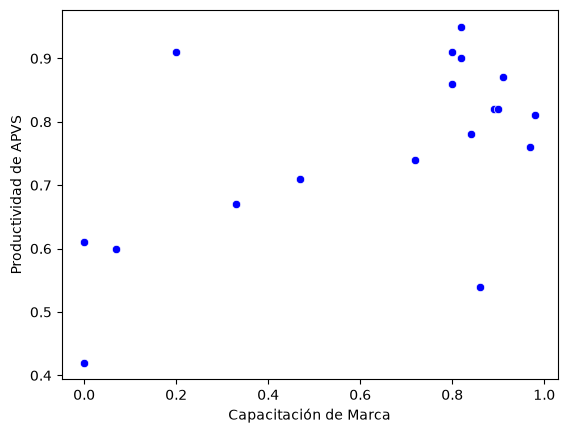

In [ ]:
#Imprimimos el scatter plot entre la variable dependiente (total) e independiente (efectivos) 
#para observar el comportamiento en su dispersión 
from turtle import color
sns.scatterplot(x='Capacitación de Marca', y='Productividad de APVS', color="blue", data=df2)

In [ ]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df2[['Capacitación de Marca']]
Var_Dep= df2['Productividad de APVS']

In [ ]:
# Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [ ]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.24]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Capacitación de Marca']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.6077
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [ ]:
# Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Capacitación de Marca'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.24091496]),
 'rank_': np.int64(1),
 'singular_': array([1.449107]),
 'intercept_': np.float64(0.6076882090247206)}

In [ ]:
# Modelo matemático:
# y= 0.24091496(Capacitación de Marca)+0.6076882090247206

In [ ]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.3423563987132683

In [ ]:
#Predecimos los valores de formalizado a partir de la variable "Capacitación de Marca"
y_pred= model.predict(X=df2[['Capacitación de Marca']])
y_pred

array([0.60768821, 0.60768821, 0.80042018, 0.80523848, 0.80042018,
       0.80523848, 0.81005677, 0.81487507, 0.82692082, 0.84137572,
       0.84378487, 0.62455226, 0.6558712 , 0.68719015, 0.72091824,
       0.78114698, 0.82210252, 0.82451167])

In [ ]:
# Insertamos la columna de predicciones en el DataFrame
df2.insert(0, 'Predicciones', y_pred)
df2

,Predicciones,Productividad de APVS,Índice de Rotación,Capacitación de Marca,Auditoría Salesforce,Plantilla con permanencia,Indice de clima laboral,Cumplimiento de plantilla
1,0.607688,0.61,0.10,0.00,0.920000,0.61,4.25,0.97
2,0.607688,0.42,0.03,0.00,0.920000,0.75,4.25,0.83
3,0.800420,0.86,0.21,0.80,0.810000,0.69,4.25,0.90
4,0.805238,0.90,0.00,0.82,0.820000,0.67,4.25,0.90
5,0.800420,0.91,0.03,0.80,0.830000,0.68,4.25,0.90
6,0.805238,0.95,0.09,0.82,0.810000,0.72,4.25,0.88
7,0.810057,0.78,0.06,0.84,0.900000,0.77,4.30,0.91
8,0.814875,0.54,0.06,0.86,0.970000,0.66,4.30,0.94
9,0.826921,0.87,0.03,0.91,0.940000,0.76,4.30,0.97
10,0.841376,0.76,0.03,0.97,0.920000,0.74,4.30,0.94


<Axes: xlabel='Capacitación de Marca', ylabel='Productividad de APVS'>

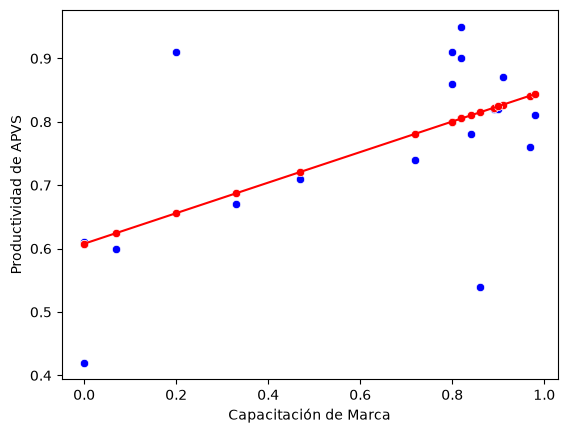

In [ ]:
#Visualizamos la gráfica comparativa entre el total real y el total predecido

sns.scatterplot(x='Capacitación de Marca', y='Productividad de APVS', color="blue", data=df2)
sns.scatterplot(x='Capacitación de Marca', y='Predicciones', color="red", data=df2)
sns.lineplot(x='Capacitación de Marca', y='Predicciones', color="red", data=df2)

In [ ]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
coef_Deter

0.3423563987132683

In [ ]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
coef_Correl

np.float64(0.5851122958144601)

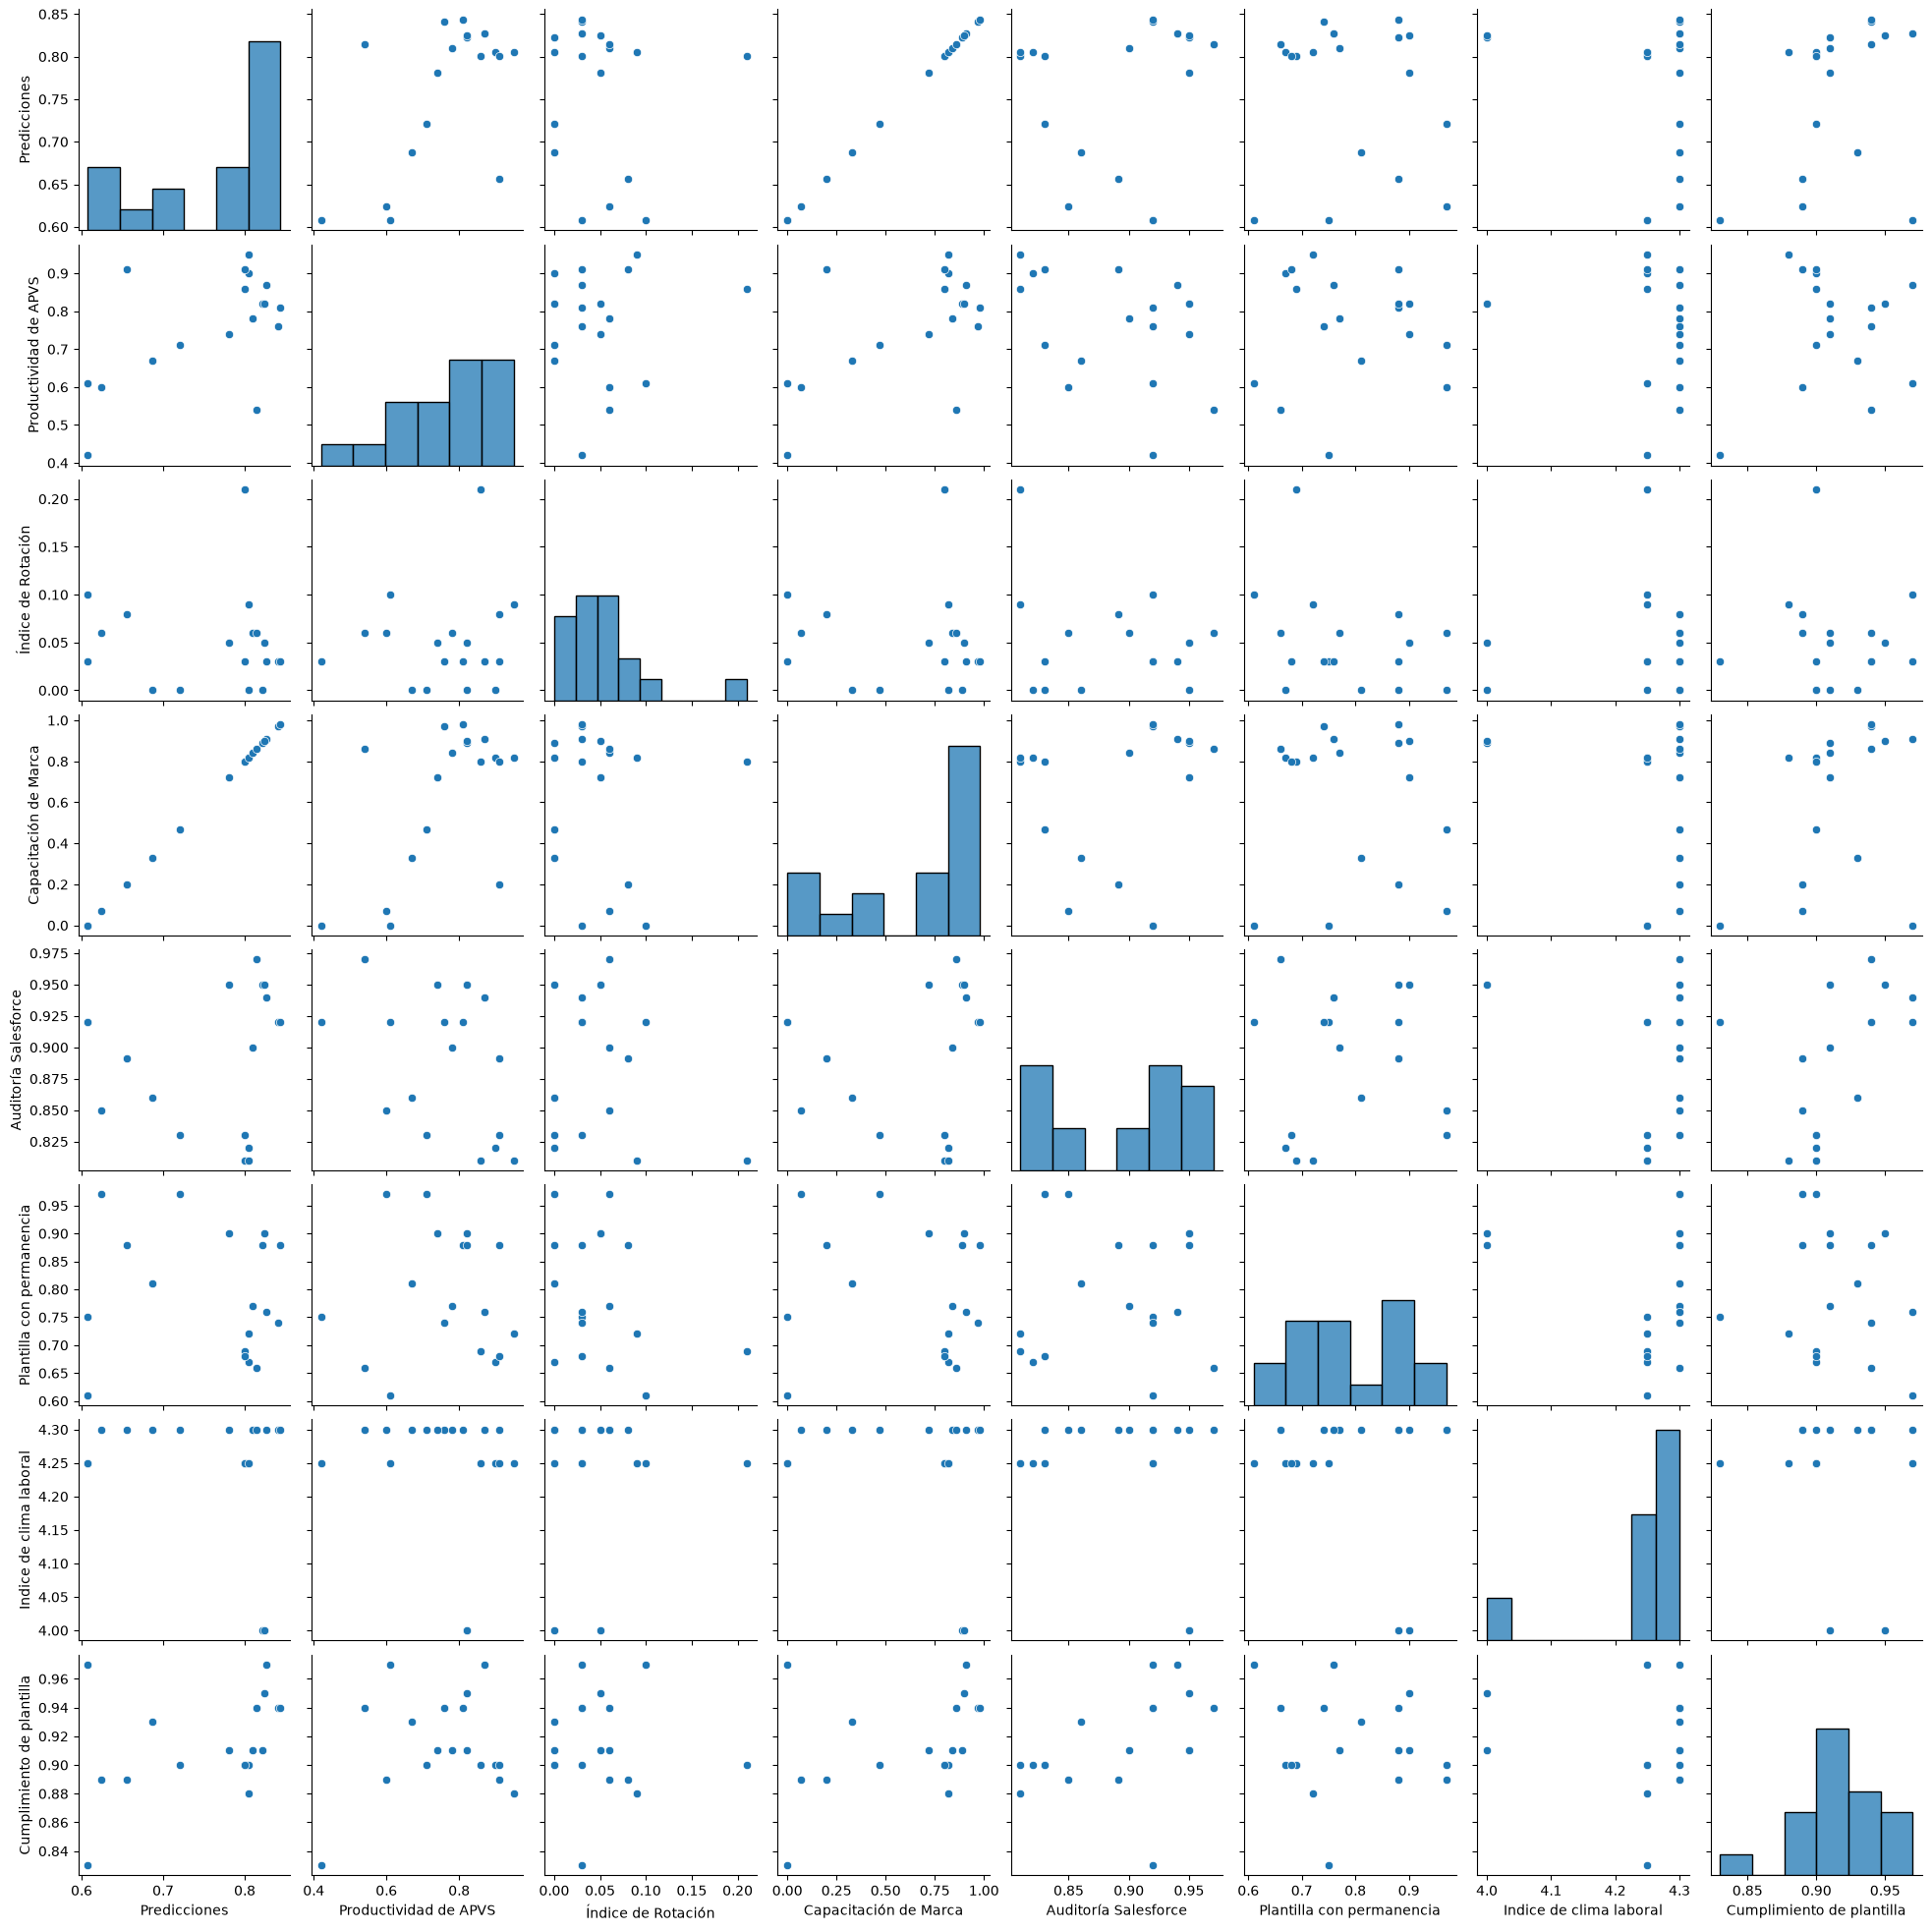

In [ ]:
#Graficamos todas las dispersiones entre todas las variables
sns.pairplot(df2)

In [ ]:
#Encontramos todas las correlaciones entre las variables 
Corr_Factors=df2.corr()
Corr_Factors

,Predicciones,Productividad de APVS,Índice de Rotación,Capacitación de Marca,Auditoría Salesforce,Plantilla con permanencia,Indice de clima laboral,Cumplimiento de plantilla
Predicciones,1.000000,0.585112,-0.068379,1.000000,0.130911,-0.109301,-0.231631,0.351050
Productividad de APVS,0.585112,1.000000,0.118148,0.585112,-0.363139,-0.010612,-0.175261,0.134953
Índice de Rotación,-0.068379,0.118148,1.000000,-0.068379,-0.226626,-0.321646,0.093501,-0.032209
Capacitación de Marca,1.000000,0.585112,-0.068379,1.000000,0.130911,-0.109301,-0.231631,0.351050
Auditoría Salesforce,0.130911,-0.363139,-0.226626,0.130911,1.000000,0.108348,-0.268598,0.444549
Plantilla con permanencia,-0.109301,-0.010612,-0.321646,-0.109301,0.108348,1.000000,-0.157846,-0.141705
Indice de clima laboral,-0.231631,-0.175261,0.093501,-0.231631,-0.268598,-0.157846,1.000000,-0.072949
Cumplimiento de plantilla,0.351050,0.134953,-0.032209,0.351050,0.444549,-0.141705,-0.072949,1.000000


<Axes: >

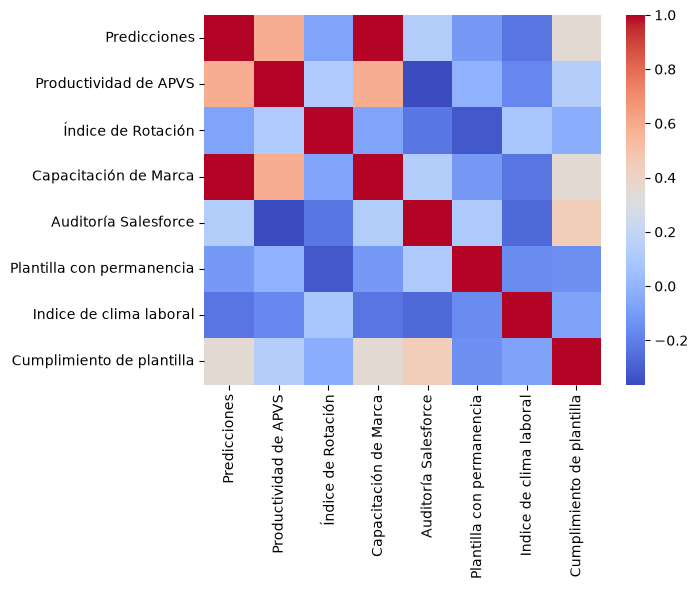

In [ ]:
#Graficamos el mapa de calor de los coeficientes de correlación 
Heat_Map= sns.heatmap(Corr_Factors, cmap = 'coolwarm')  
Heat_Map

<Axes: >

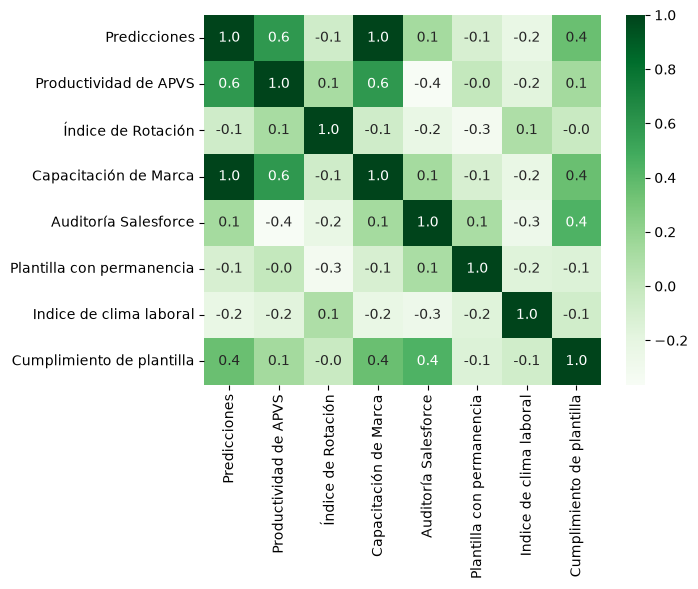

In [ ]:
#Ajustamos el mapa de calor de los coeficientes de correlación 
Heat_Map= sns.heatmap(Corr_Factors, cmap = 'Greens', annot=True, fmt=".1f")  
Heat_Map